In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams.update({
    'font.size': 16,
    'text.usetex': True,
    'axes.titlesize': 'large',  # Title size
    'axes.titleweight': 'bold',  
    'axes.labelsize': 'LARGE',  
    'axes.labelweight': 'bold',  
    'xtick.labelsize': 'medium',  
    'ytick.labelsize': 'medium',  
    'text.latex.preamble': r'\boldmath',
})

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.minor.width'] = 1
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [2]:
L = 10
temp = np.linspace(2.269, 5, 10)
temp = [temp[0], temp[-7], temp[-3], temp[-1]]

In [3]:
output_dir = "Data2/L_10/Hamming_Distances"
os.makedirs(output_dir, exist_ok=True)


loaded_distances = []
for T in temp:
    filepath = os.path.join(output_dir, f"hamming_dist_T_{T}.npy")
    array = np.load(filepath)
    loaded_distances.append(array)

In [4]:
new_dist = []
for i in range(len(temp)):
    new_dist.append(np.loadtxt(f"Data2/L_10/Hamming_Distances/new_distances_T_{temp[i]}.txt"))

In [5]:
def modifiy(index, loaded_distances):
    dist_load = loaded_distances[index]
    modified_load = [np.insert(arr, i, 0) for i, arr in enumerate(dist_load)]
    modified_load = np.array(modified_load)

    return modified_load

In [6]:
def weights_computation(index, loaded_distances):
    load_high_temp = loaded_distances[index]
    weights = 1/load_high_temp
    weights_n = modifiy(0, [weights])
    return weights_n

In [7]:
def Q_values(weights):
    Q_values = []
    for i in range(len(weights)):
        q = np.sum(weights[i])
        Q_values.append(q)
    return Q_values

In [8]:
weights_temp_tc = weights_computation(0, loaded_distances)
weights_temp_3 = weights_computation(1, loaded_distances)
weights_temp_4 = weights_computation(2, loaded_distances)
weights_temp_5 = weights_computation(3, loaded_distances)

In [9]:
weights_temp_tc = np.array(weights_temp_tc)
weights_temp_3 = np.array(weights_temp_3)
weights_temp_4 = np.array(weights_temp_4)
weights_temp_5 = np.array(weights_temp_5)

In [10]:
Q_values_tc = Q_values(weights_temp_tc)
Q_values_3 = Q_values(weights_temp_3)
Q_values_4 = Q_values(weights_temp_4)
Q_values_5 = Q_values(weights_temp_5)

In [11]:
loaded_distances[0]

array([[ 16.,  22.,  34., ..., 158., 158., 162.],
       [ 16.,  22.,  42., ..., 154., 154., 158.],
       [ 22.,  22.,  24., ..., 144., 152., 156.],
       ...,
       [158., 154., 144., ...,  14.,  20.,  24.],
       [158., 154., 152., ...,  18.,  20.,  12.],
       [162., 158., 156., ...,  18.,  24.,  12.]])

In [12]:
np.sum(weights_temp_tc[0]), np.sum(weights_temp_3[0]), np.sum(weights_temp_4[0]), np.sum(weights_temp_5[0])

(10.046693638314414,
 102.11137940235304,
 101.56163952751417,
 101.12452175125658)

In [13]:
np.max(loaded_distances[0][-1])

198.0

In [14]:
np.max(loaded_distances[-1][0])

142.0

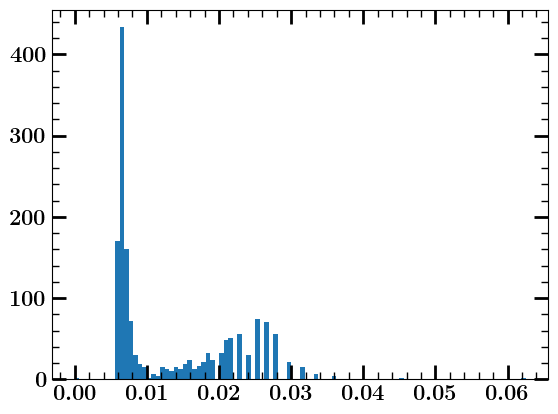

In [15]:
plt.hist(weights_temp_tc[0], bins=100, density = True)
plt.show()

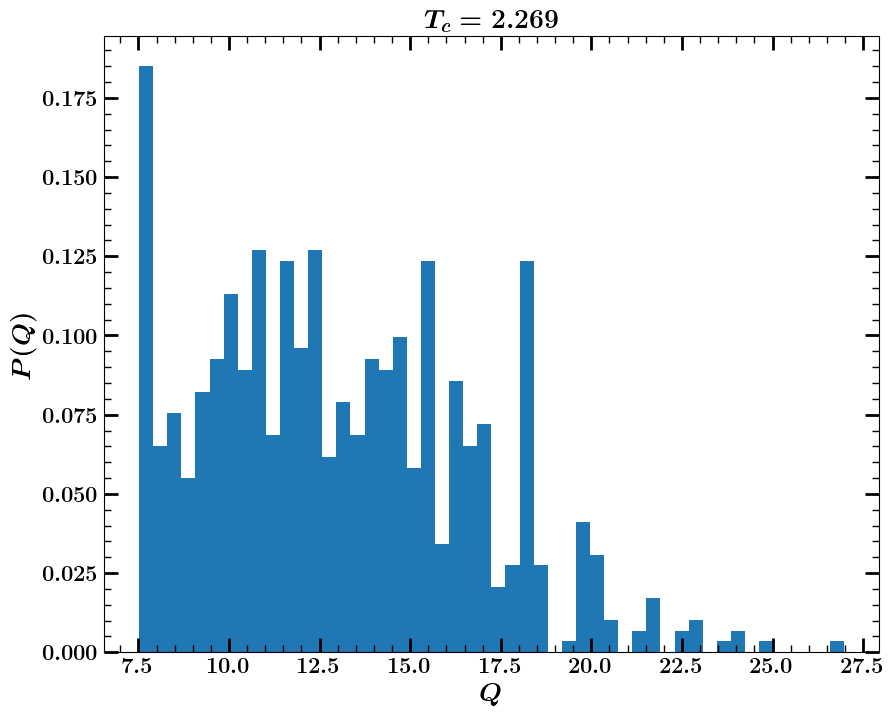

In [25]:
plt.figure(figsize=(10, 8))
a = plt.hist(Q_values_tc, density = True, bins = 50)
plt.xlabel(r"$Q$")
plt.ylabel(r"$P(Q)$")
plt.xticks()
plt.yticks()
plt.title(r"$T_c = 2.269$")
plt.savefig("Data2/L_10/Hamming_Distances/Q_values_Tc.pdf")
plt.show()

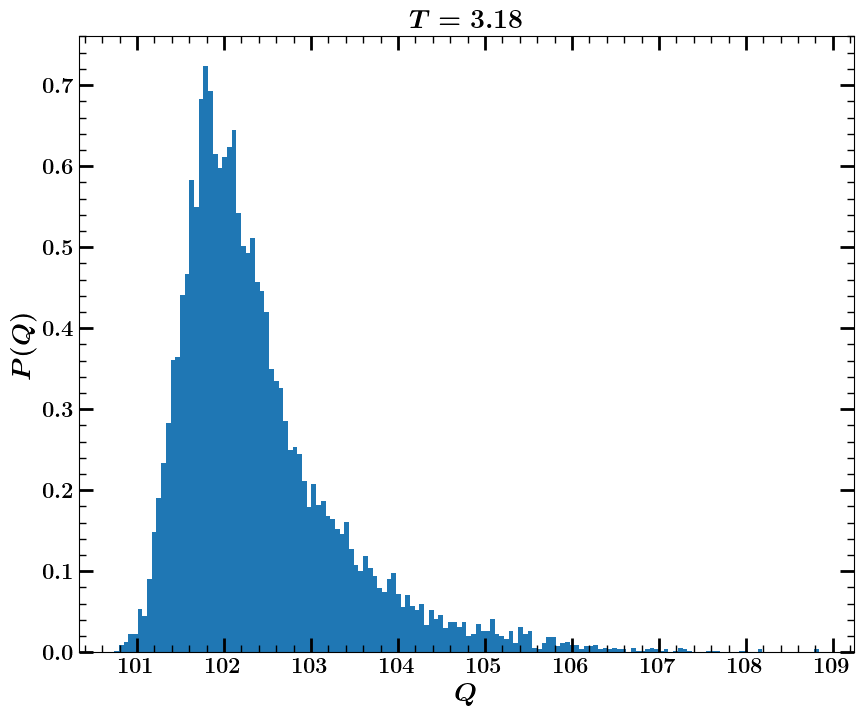

In [26]:
plt.figure(figsize=(10, 8))
b = plt.hist(Q_values_3, density = True, bins = 150)
plt.xlabel(r"$Q$")
plt.ylabel(r"$P(Q)$")
plt.xticks()
plt.yticks()
plt.title(r"$T = 3.18$")
plt.savefig("Data2/L_10/Hamming_Distances/Q_values_3.pdf")
plt.show()

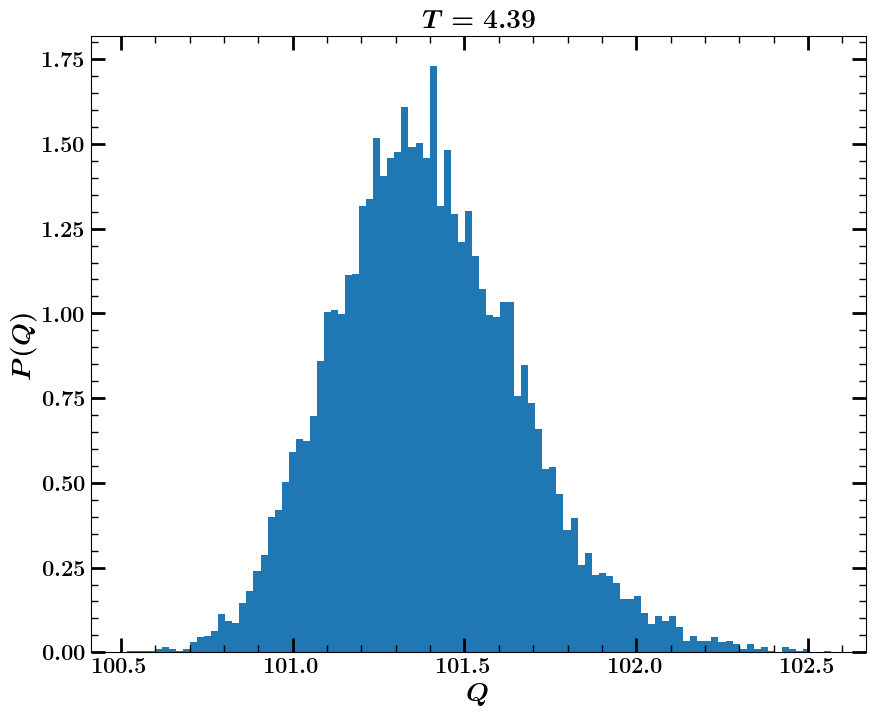

In [27]:
plt.figure(figsize=(10, 8))
c = plt.hist(Q_values_4, density = True, bins = 100)
plt.xlabel(r"$Q$")
plt.ylabel(r"$P(Q)$")
plt.xticks()
plt.yticks()
plt.title(r"$T = 4.39$")
plt.savefig("Data2/L_10/Hamming_Distances/Q_values_4.pdf")
plt.show()

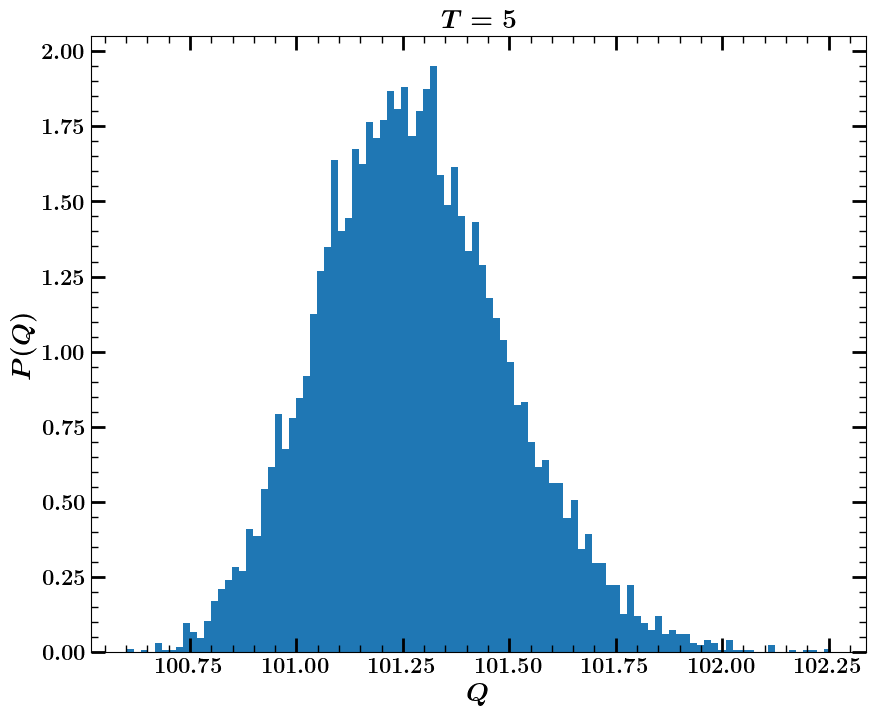

In [28]:
plt.figure(figsize=(10, 8))
d = plt.hist(Q_values_5, density = True, bins = 100)
plt.xlabel(r"$Q$")
plt.ylabel(r"$P(Q)$")
plt.xticks()
plt.yticks()
plt.title(r"$T = 5$")
plt.savefig("Data2/L_10/Hamming_Distances/Q_values_5.pdf")
plt.show()

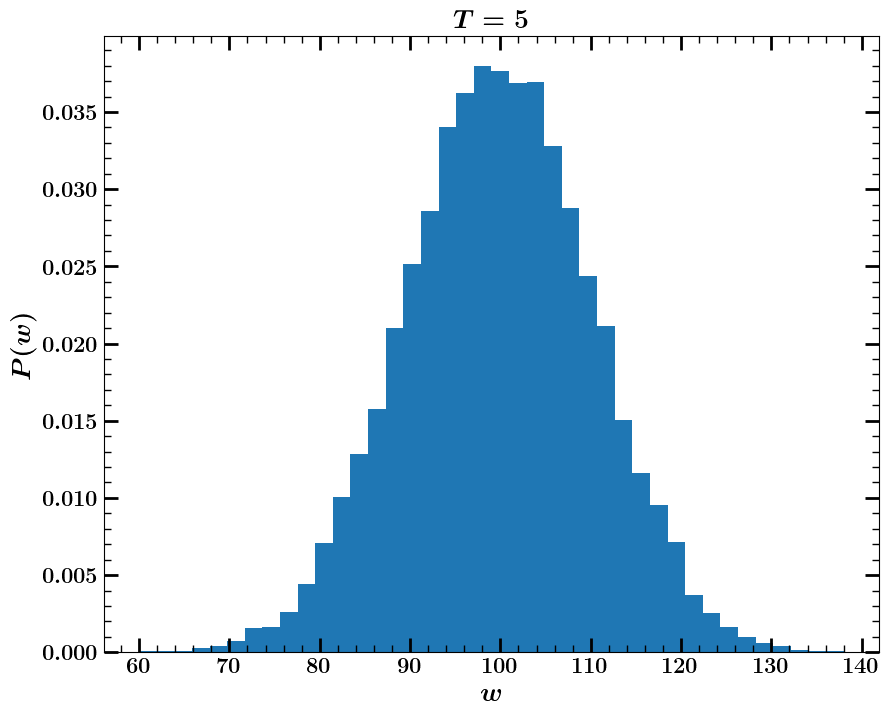

In [20]:
plt.figure(figsize=(10, 8))
plt.hist(loaded_distances[-1][5], bins=40, density = True)
plt.ylabel(r"$P(w)$")
plt.xlabel(r"$w$")
plt.title(r"$T = 5$")
plt.show()

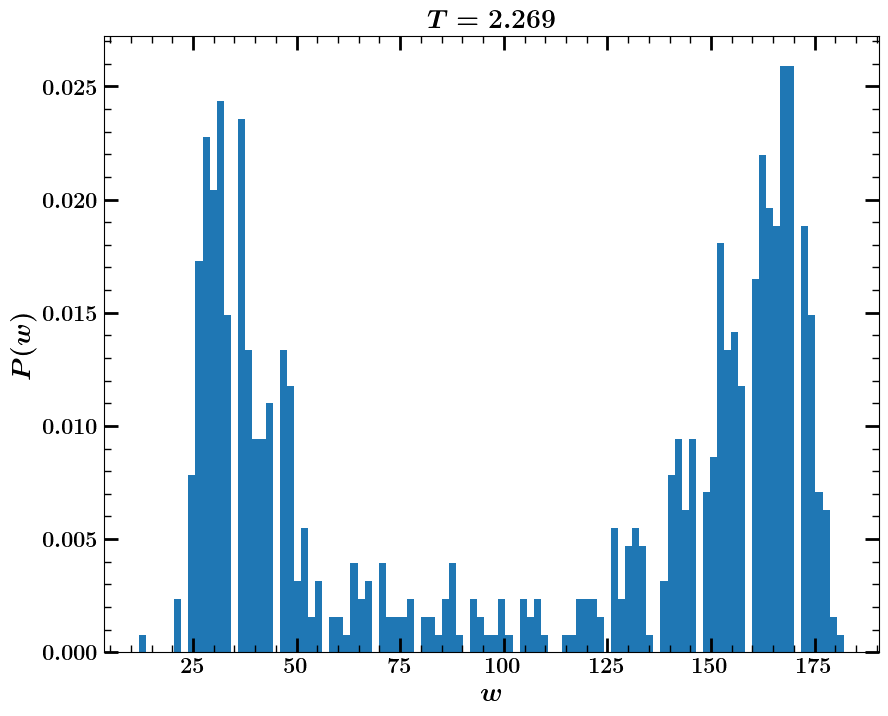

In [21]:
plt.figure(figsize=(10, 8))
plt.hist(loaded_distances[0][10], bins=100, density = True)
plt.ylabel(r"$P(w)$")
plt.xlabel(r"$w$")
plt.title(r"$T = 2.269$")
plt.show()

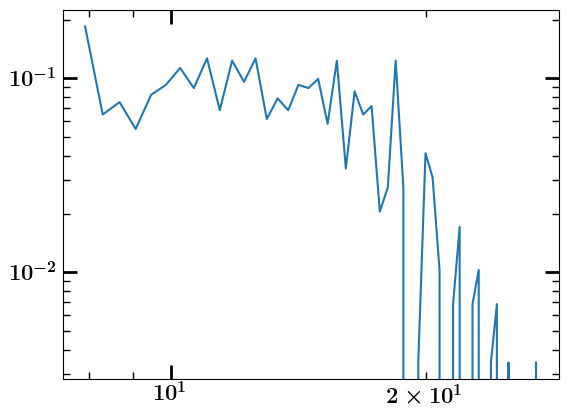

In [42]:
plt.plot(a[1][1:], a[0], label = r"$T_c = 2.269$")
plt.xscale("log")
plt.yscale("log")

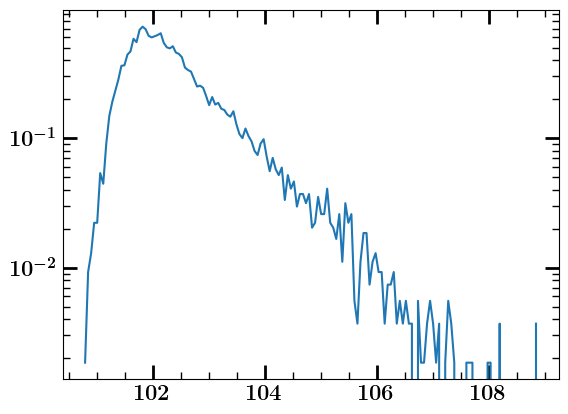

In [44]:
plt.plot(b[1][1:], b[0], label = r"$T_c = 3$")
plt.yscale("log")

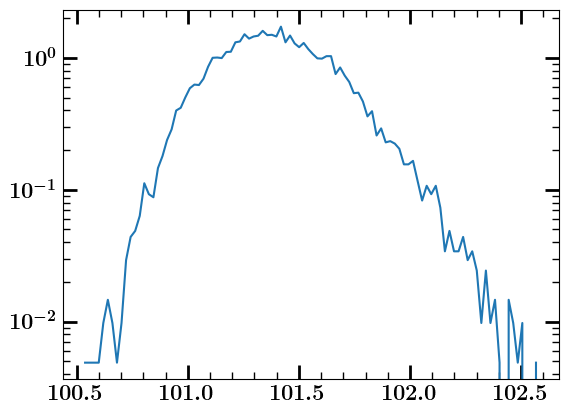

In [45]:
plt.plot(c[1][1:], c[0], label = r"$T_c = 4.39$")
plt.yscale("log")

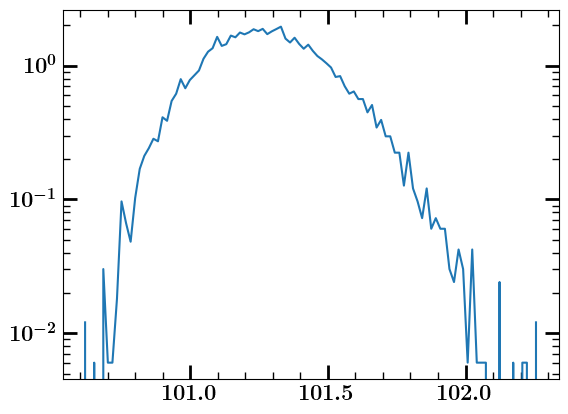

In [46]:
plt.plot(d[1][1:], d[0], label = r"$T_c = 5.0$")
plt.yscale("log")